In [19]:
import numpy as np 
import pandas as pd
from sklearn.preprocessing import StandardScaler #normalization
from sklearn.model_selection import train_test_split #split training and testing data
import matplotlib.pyplot as plt #graphs
from sklearn.model_selection import GridSearchCV #parameter tuning
import seaborn as sns
from sklearn import neighbors #KNN
from sklearn.ensemble import RandomForestRegressor #RF
from sklearn.datasets import make_regression
from math import sqrt
from sklearn.svm import SVR #SVM
from sklearn.linear_model import LinearRegression #LR
from sklearn.ensemble import GradientBoostingRegressor #GBR
from sklearn.metrics import mean_squared_error #EVALUATION
from sklearn.metrics import mean_absolute_error 
from sklearn.metrics import r2_score

## Normalization

In [20]:
df = pd.read_csv('godsaveme.csv')

In [39]:
scaler = StandardScaler()  
df['normalized_avg_stress'] = scaler.fit_transform(df[['Average Stress']])
df.head(10)

,12,14,15,23,24,25,26,35,36,45,...,56,57,58,59,68,69,78,89,Average Stress,normalized_avg_stress
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,3290000.0,0.019286
1,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,1,0,0,11500000.0,2.020251
2,0,0,0,0,0,0,0,0,0,0,...,1,0,1,0,0,1,0,0,2370000.0,-0.204939
3,0,0,0,0,0,0,0,0,0,0,...,1,0,1,0,0,0,0,1,9320000.0,1.488935
4,0,0,0,0,0,0,0,0,0,0,...,1,0,1,0,0,0,0,0,13900000.0,2.605186
5,0,0,0,0,0,0,0,0,0,0,...,1,0,1,0,0,1,0,1,1960000.0,-0.304866
6,0,0,0,0,0,0,0,0,0,0,...,1,0,1,1,0,1,0,1,1450000.0,-0.429164
7,0,0,0,0,0,0,0,0,0,0,...,1,0,1,1,0,0,0,1,6020000.0,0.684649
8,0,0,0,0,0,0,0,0,0,0,...,1,0,1,1,0,1,0,0,1740000.0,-0.358485
9,0,0,0,0,0,0,0,0,0,0,...,1,0,1,1,0,0,0,0,7360000.0,1.011238


## Splitting the Dataset

In [40]:
X=df[["12","14","15","23","24","25","26","35","36","45","47","48","56","57","58","59","68","69","78","89"]]
Y=df["normalized_avg_stress"]

X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size=0.3,random_state=42)

In [41]:
#make a version for the mass prediction? 

## K-NN

In [42]:
rmse_val = [] #to store rmse values for different k
for K in range(20):
    K = K+1
    model = neighbors.KNeighborsRegressor(n_neighbors = K)

    model.fit(X_train, y_train)  #fit the model
    pred=model.predict(X_test) #make prediction on test set
    error = sqrt(mean_squared_error(y_test,pred)) #calculate rmse
    rmse_val.append(error) #store rmse values
    print('RMSE value for k= ' , K , 'is:', error)

RMSE value for k=  1 is: 0.6718911197536708
RMSE value for k=  2 is: 0.8172916072509296
RMSE value for k=  3 is: 0.7973154939861335
RMSE value for k=  4 is: 0.8050812946003267
RMSE value for k=  5 is: 0.8533904956369209
RMSE value for k=  6 is: 0.9014776430820325
RMSE value for k=  7 is: 0.9394637762553935
RMSE value for k=  8 is: 0.9742027941407897
RMSE value for k=  9 is: 0.9821645522260041
RMSE value for k=  10 is: 1.0162498201466121
RMSE value for k=  11 is: 1.029349565007273
RMSE value for k=  12 is: 1.046468143324831
RMSE value for k=  13 is: 1.044614496818939
RMSE value for k=  14 is: 1.0540807259561573
RMSE value for k=  15 is: 1.0642074817701295
RMSE value for k=  16 is: 1.0385582135849103
RMSE value for k=  17 is: 1.0515614951559653
RMSE value for k=  18 is: 1.0587291885193935
RMSE value for k=  19 is: 1.0693669880446837
RMSE value for k=  20 is: 1.0838419465148459


<AxesSubplot:>

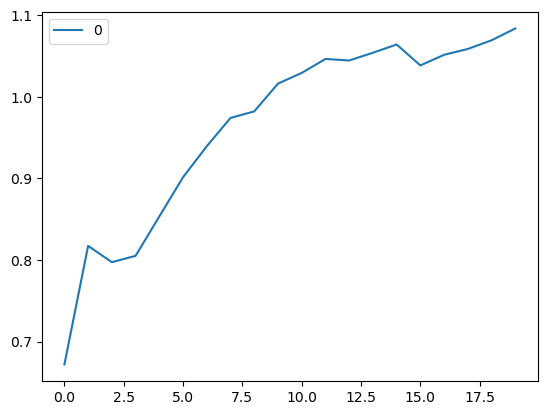

In [43]:
curve = pd.DataFrame(rmse_val) #elbow curve 
curve.plot()

In [44]:
params = {'n_neighbors':[2,3,4,5,6,7,8,9]}

knn = neighbors.KNeighborsRegressor()

model = GridSearchCV(knn, params, cv=5)
model.fit(X_train,y_train)
model.best_params_

{'n_neighbors': 7}

In [45]:
knn.fit(X_train,y_train)
prediction_knn = knn.predict(X_test)
mse = mean_squared_error(y_test, prediction_knn)
rmse = mse**.5
mae = mean_absolute_error(y_test, prediction_knn)
r2 = r2_score(y_test, prediction_knn)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

MSE: 0.7282753380434295
RMSE: 0.8533904956369209
MAE: 0.4940246690922211
R2: 0.49608222116430933


## Random Forest

In [46]:
params = { 
    'n_estimators': [200,300,400,500],
    'max_features': ['sqrt','log2'],
    'max_depth' : [3,4,5,6,7],
    'random_state' : [18]
}
rf = RandomForestRegressor()

model = GridSearchCV(rf, params, cv=5)
model.fit(X_train,y_train)
model.best_params_

{'max_depth': 5,
 'max_features': 'sqrt',
 'n_estimators': 200,
 'random_state': 18}

In [55]:
rf = RandomForestRegressor(n_estimators = 200, max_features = 'sqrt', max_depth = 5, random_state = 18).fit(X_train, y_train)

In [56]:
rf.fit(X_train,y_train)
prediction_rf = rf.predict(X_test)
mse = mean_squared_error(y_test, prediction_rf)
rmse = mse**.5
mae = mean_absolute_error(y_test, prediction_rf)
r2 = r2_score(y_test, prediction_rf)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

MSE: 0.7631171924826311
RMSE: 0.8735657917310127
MAE: 0.4977518514070649
R2: 0.4719739904137139


## Support Vector Machine

In [49]:
params = { 
    'kernel' : ('linear', 'poly', 'rbf', 'sigmoid'),
    'C' : [1,5,10],
    'degree' : [3,8],
    'coef0' : [0.01,10,0.5],
    'gamma' : ('auto','scale')
}
svr = SVR()

model = GridSearchCV(svr, params, cv=5)
model.fit(X_train,y_train)
model.best_params_

{'C': 1, 'coef0': 0.01, 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf'}

In [57]:
svr = SVR(kernel = 'rbf', C = 1, coef0 = 0.01, degree = 3, gamma = 'scale')

In [58]:
svr.fit(X_train, y_train)
prediction_svr = svr.predict(X_test)
mse = mean_squared_error(y_test, prediction_svr)
rmse = mse**.5
mae = mean_absolute_error(y_test, prediction_svr)
r2 = r2_score(y_test, prediction_svr)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

MSE: 1.0053622020234165
RMSE: 1.0026775164644994
MAE: 0.47828124882084216
R2: 0.3043566611357811


## Linear Regression

In [59]:
params = {
    "fit_intercept": [True, False], 
}

##'copy_X', 'fit_intercept', 'n_jobs', 'positive' check these values

lr = LinearRegression()

model = GridSearchCV(lr, params, cv=5)
model.fit(X_train,y_train)
model.best_params_

{'fit_intercept': True}

In [60]:
lr = LinearRegression(fit_intercept = True)

In [54]:
y_pred_lr = lr.predict(X_test)
plt.scatter(X_test, y_test, color ='b') ##maybe test_size 0.5?
plt.plot(X_test, y_pred, color ='k')

plt.show() 


#df_binary500 = df_binary[:][:500]
   
# Selecting the 1st 500 rows of the data
#sns.lmplot(x ="Sal", y ="Temp", data = df_binary500,
# order = 2, ci = None) ##work with smaller data to see clearer
##https://www.geeksforgeeks.org/python-linear-regression-using-sklearn/

NotFittedError: This LinearRegression instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [61]:
lr.fit(X_train, y_train)
prediction_lr = lr.predict(X_test)
mse = mean_squared_error(y_test, prediction_lr)
rmse = mse**.5
mae = mean_absolute_error(y_test, prediction_lr)
r2 = r2_score(y_test, prediction_svr)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

MSE: 0.960321769432646
RMSE: 0.9799600856323925
MAE: 0.5512405813301133
R2: 0.3043566611357811


## Gradient Boosting

In [62]:
params = {
    'max_depth':range(5,16,2), 
    'min_samples_split':range(200,1001,200) 
}

gbr = GradientBoostingRegressor()

model = GridSearchCV(gbr, params, cv=5)
model.fit(X_train,y_train)
model.best_params_

{'max_depth': 5, 'min_samples_split': 200}

In [63]:
gbr = GradientBoostingRegressor(max_depth = 5, min_samples_split = 200)

In [64]:
gbr.fit(X_train, y_train)
prediction_gbr = gbr.predict(X_test)
mse = mean_squared_error(y_test, prediction_gbr)
rmse = mse**.5
mae = mean_absolute_error(y_test, prediction_gbr)
r2 = r2_score(y_test, prediction_svr)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

MSE: 1.4867836367626375
RMSE: 1.2193373761033643
MAE: 0.7448846916882406
R2: 0.3043566611357811
